In [ ]:
# import libraries and set plotting defaults.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# load raw dataset and preview shape and sample rows.
# Load the dataset
df = pd.read_csv('../data/raw/diabetes_health_indicators.csv')

print("Dataset Shape:", df.shape)
print("First Few Rows:")
print(df.head())

Dataset Shape: (253680, 22)
First Few Rows:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0

In [ ]:
# show dataframe schema and data types.
# Display dataset information
print("Dataset Info:")
print(df.info())
print("\nData Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null 

In [ ]:
# display descriptive statistics for numeric columns.
# Basic statistical summary
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001       0.424121       0.962670   
std           0.346294       0.494934       0.494210       0.189571   
min           0.000000       0.000000       0.000000       0.000000   
25%           0.000000       0.000000       0.000000       1.000000   
50%           0.000000       0.000000       0.000000       1.000000   
75%           0.000000       1.000000       1.000000       1.000000   
max           1.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0.094186   
std         6.608694       0.496761       0.197294              0.292087   
min        12.000000       0.000000

In [ ]:
# check missing values and duplicate rows.
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

Missing Values:
No missing values

Duplicate Rows: 24206


In [ ]:
# inspect unique value counts for each feature.
# Explore unique values in each column
print("Unique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].nunique() <= 10:
        print(f"  Values: {sorted(df[col].unique())}\n")

Unique Values per Column:
Diabetes_binary: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

HighBP: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

HighChol: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

CholCheck: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

BMI: 84 unique values
Smoker: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

Stroke: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

HeartDiseaseorAttack: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

PhysActivity: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

Fruits: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

Veggies: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

HvyAlcoholConsump: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

AnyHealthcare: 2 unique values
  Values: [np.float64(0.0), np.float64(1.0)]

NoDocbcCost: 2 unique values
  Values: [np.float64(0.0), np

In [ ]:
# set and validate target column, then print class distribution.
# Set target variable based on project proposal
target_col = 'Diabetes_binary'

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available columns: {list(df.columns)}")

print(f"Target Variable: {target_col}")
print("\nTarget Distribution:")
print(df[target_col].value_counts())
print("\nTarget Distribution (%):")
print(df[target_col].value_counts(normalize=True) * 100)

Target Variable: Diabetes_binary

Target Distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Target Distribution (%):
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


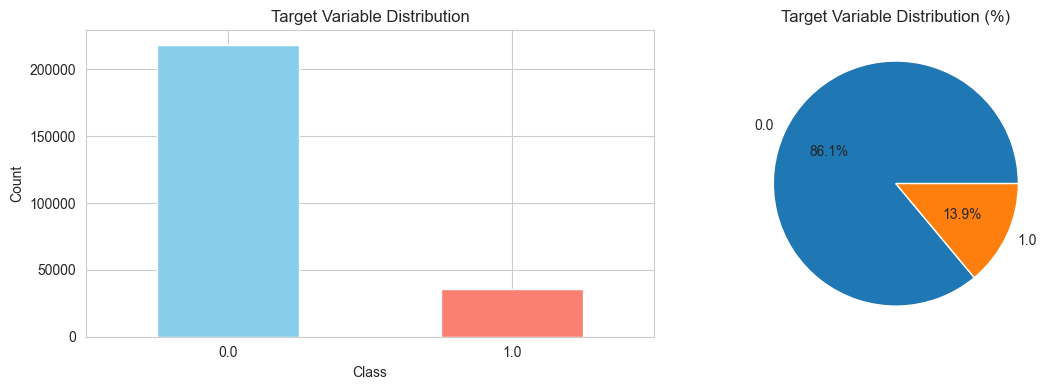

In [ ]:
# visualize target class balance with bar and pie charts.
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Target Variable Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

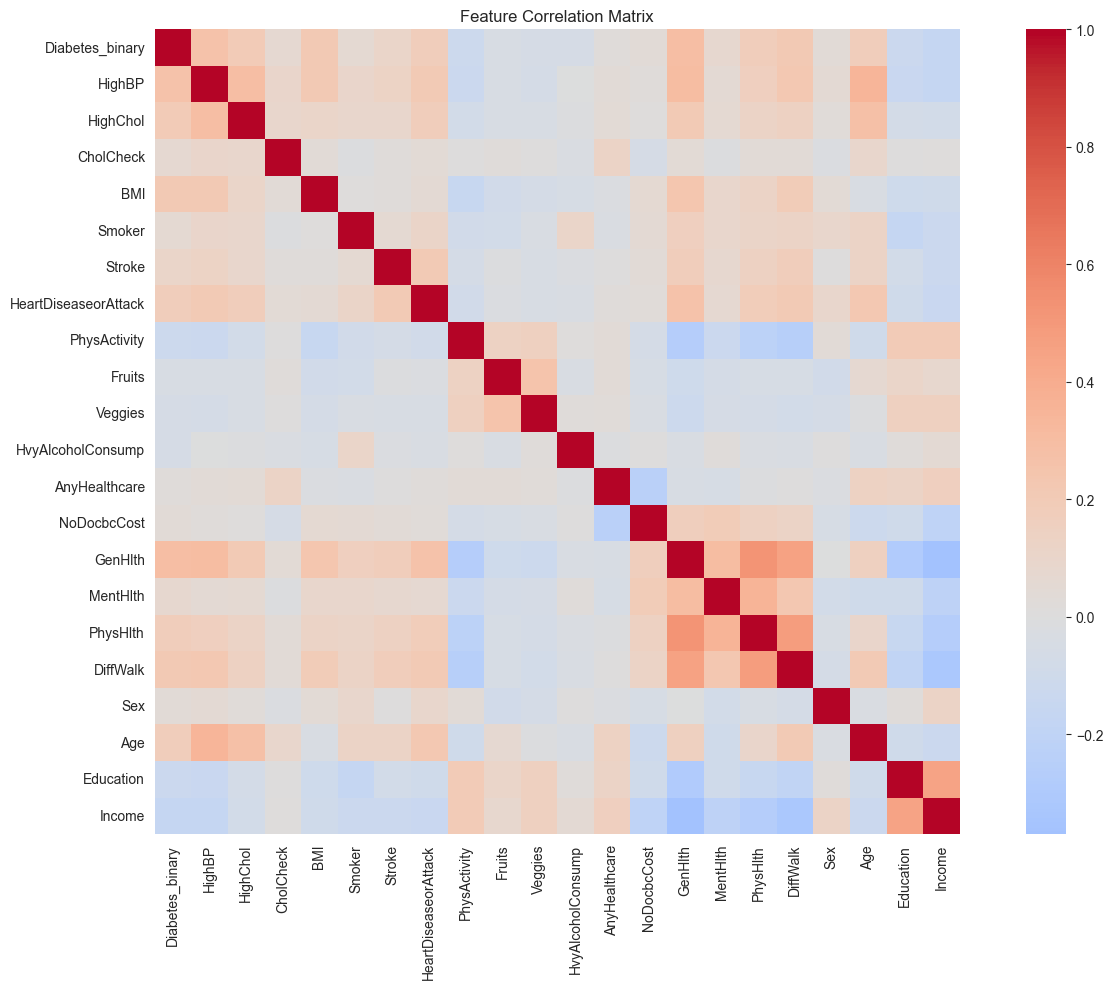

In [ ]:
# compute and plot the full correlation matrix heatmap.
# Correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# rank features by correlation with the target variable.
# Correlation with target variable
target_correlation = correlation_matrix[target_col].sort_values(ascending=False)
print(f"\nTop 10 Features Correlated with {target_col}:")
print(target_correlation.head(10))

print(f"\nBottom 10 Features Correlated with {target_col}:")
print(target_correlation.tail(10))


Top 10 Features Correlated with Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
Name: Diabetes_binary, dtype: float64

Bottom 10 Features Correlated with Diabetes_binary:
Smoker               0.060789
NoDocbcCost          0.031433
Sex                  0.031430
AnyHealthcare        0.016255
Fruits              -0.040779
Veggies             -0.056584
HvyAlcoholConsump   -0.057056
PhysActivity        -0.118133
Education           -0.124456
Income              -0.163919
Name: Diabetes_binary, dtype: float64


In [ ]:
# identify numeric features excluding the target column.
# Get numeric columns (excluding target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != target_col]

print(f"Number of numeric features: {len(numeric_cols)}")
print(f"Features: {list(numeric_cols)}")

Number of numeric features: 21
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


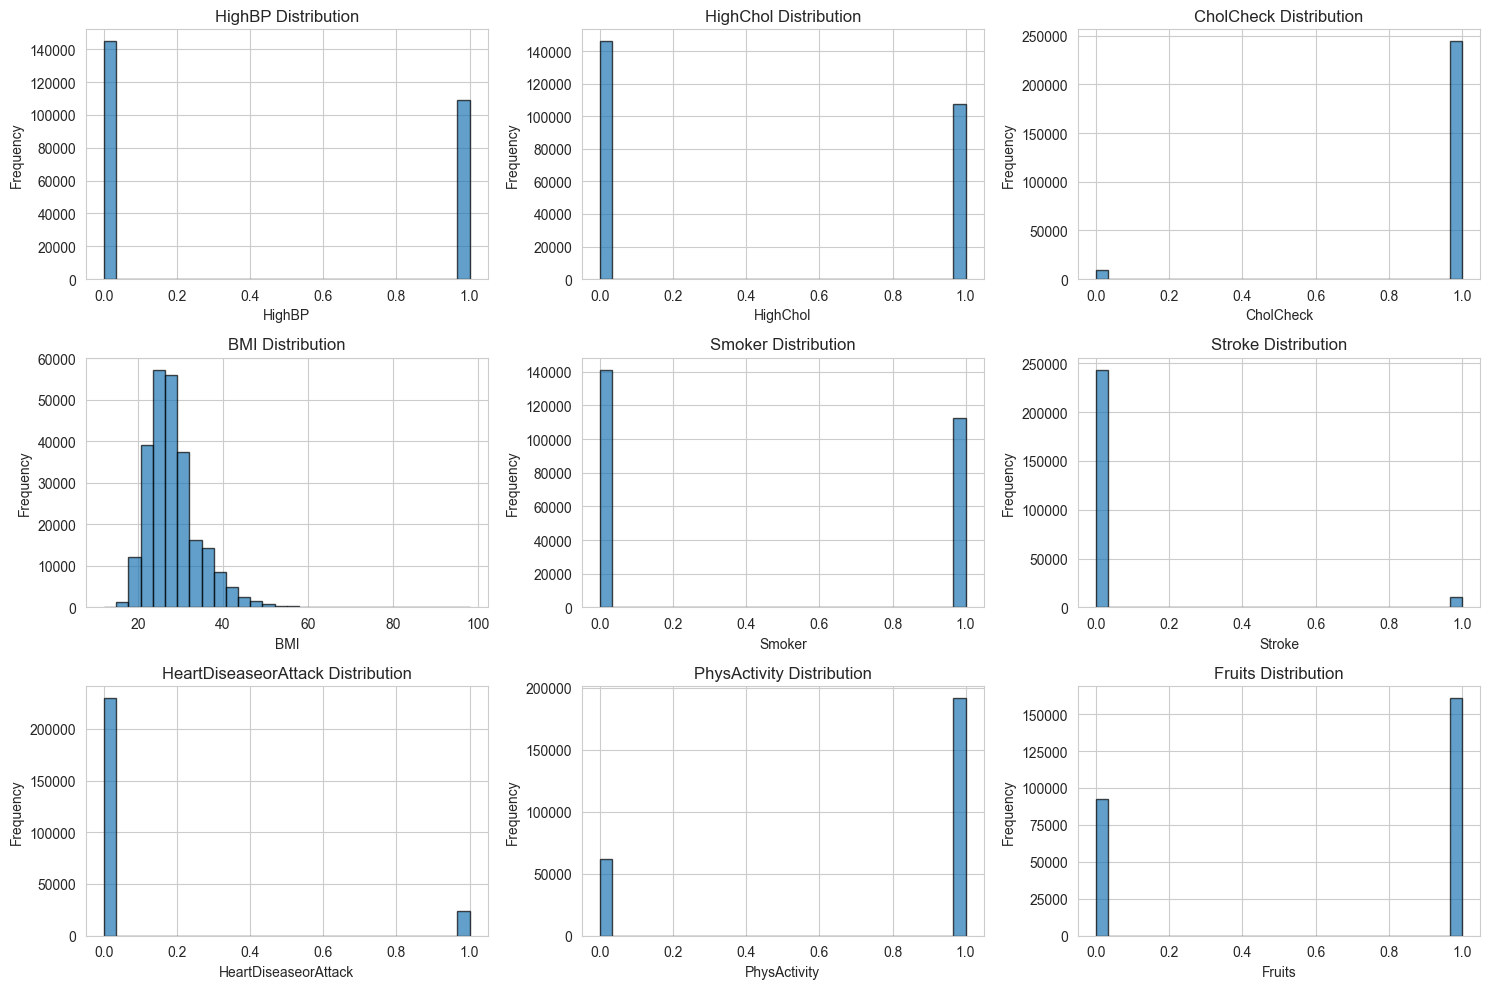

In [ ]:
# visualize numeric feature distributions with histograms.
# Distribution plots for first 9 numeric features
n_cols = min(9, len(numeric_cols))
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:n_cols]):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide extra subplots
for idx in range(n_cols, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

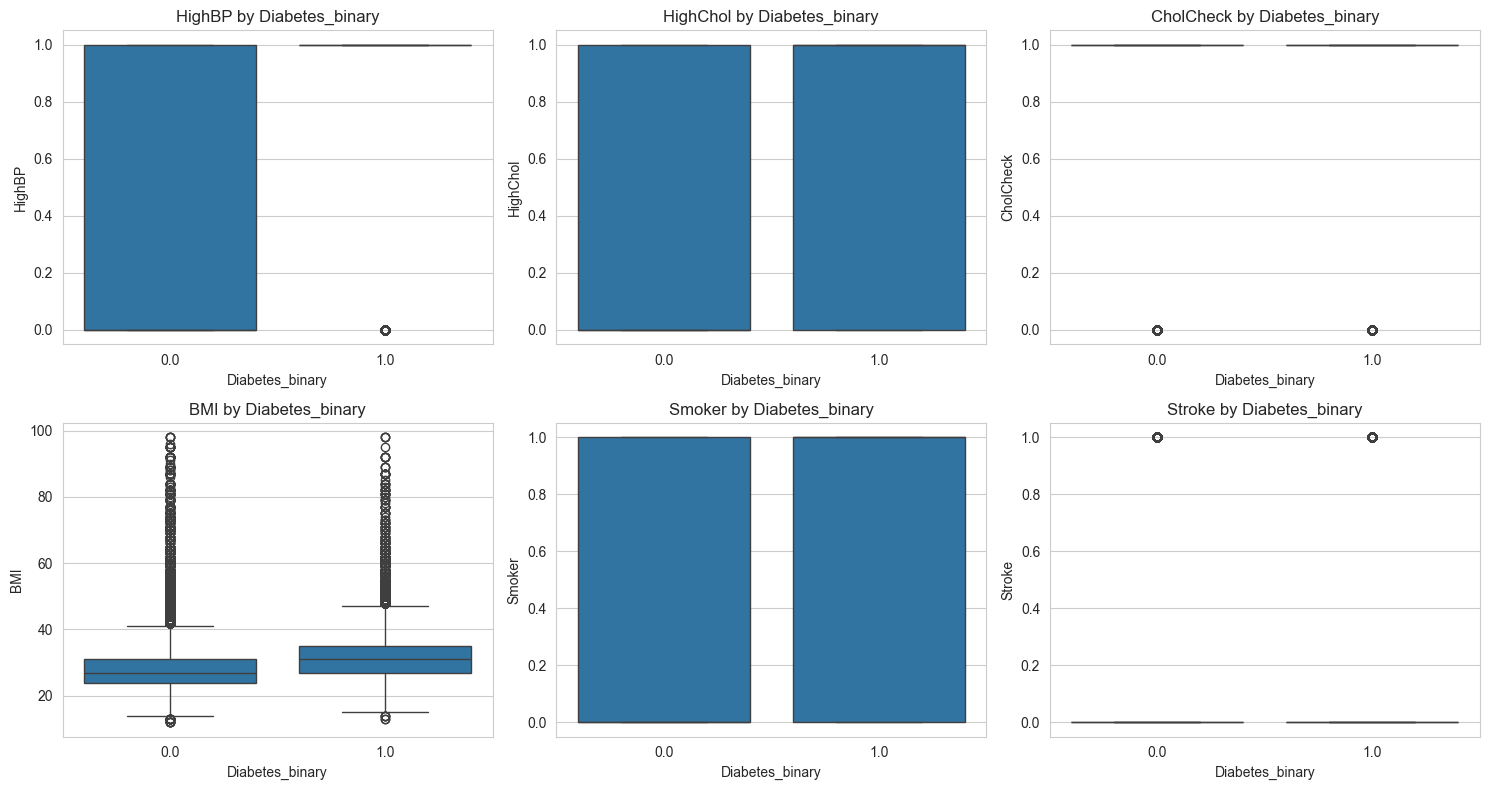

In [ ]:
# compare numeric feature distributions by target using boxplots.
# Box plots by target class for numeric features
n_cols = min(6, len(numeric_cols))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:n_cols]):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[idx])
    axes[idx].set_title(f'{col} by {target_col}')

plt.tight_layout()
plt.show()

In [ ]:
# print final EDA summary statistics and key correlations.
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print(f"Dataset Shape: {df.shape}")
print(f"Number of Features: {len(df.columns) - 1}")
print(f"Number of Samples: {len(df)}")
print(f"\nTarget Variable: {target_col}")
print(f"Class Distribution:")
print(df[target_col].value_counts().to_string())
print(f"\nClass Balance: {min(df[target_col].value_counts()) / len(df) * 100:.2f}% (least frequent)")
print(f"\nMissing Values: {'None' if df.isnull().sum().sum() == 0 else df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"\nTop 5 Features Correlated with Target:")
for idx, (feature, corr) in enumerate(target_correlation[1:6].items(), 1):
    print(f"  {idx}. {feature}: {corr:.4f}")


EXPLORATORY DATA ANALYSIS SUMMARY
Dataset Shape: (253680, 22)
Number of Features: 21
Number of Samples: 253680

Target Variable: Diabetes_binary
Class Distribution:
Diabetes_binary
0.0    218334
1.0     35346

Class Balance: 13.93% (least frequent)

Missing Values: None
Duplicate Rows: 24206

Top 5 Features Correlated with Target:
  1. GenHlth: 0.2936
  2. HighBP: 0.2631
  3. DiffWalk: 0.2183
  4. BMI: 0.2168
  5. HighChol: 0.2003
